# Logarithms, Made Clear as a Summer Day on the Lake
### *The why, what, how, and when, with finance and immunization as our running examples*

**How to use this notebook:** read a section, then play with the sliders right below it. Don't skip the sliders. The goal is for your *hands* to learn what logs do, not just your eyes.

**Run it:** `Kernel → Restart & Run All`, then use the widgets. Needs `numpy`, `pandas`, `matplotlib`, `ipywidgets`.

**Map of the trip**

| Part | Question it answers |
|---|---|
| 1 | **What** is a logarithm, really? |
| 2 | **Why** do we need one? (Multiplication → addition) |
| 3 | **How** do the rules work, and what is `ln` / `e`? |
| 4 | **When** do logs show up? (Log scales, straight lines) |
| 5 | **Finance:** doubling time, Rule of 72, log returns, goal timing |
| 6 | **Immunization:** outbreak growth, antibody titers, elimination countdown |
| 7 | Cheat sheet + practice problems |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as w
from ipywidgets import interact
from IPython.display import display, Markdown

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Ready.")

Ready.


---
# Part 1: What *is* a logarithm?

### Why your brain might hate them
Logarithms usually get taught as a mysterious button on a calculator, or as a definition like *"log_b(x) is the exponent to which b must be raised to yield x"*. That sentence is correct and almost useless for building intuition. Let's replace it.

### The one-sentence version
> **A logarithm counts how many times you multiplied.**

That's it. If you start at 1 and keep multiplying by 10:

| Multiplications by 10 | Number you get | Looks like |
|---|---|---|
| 1 | 10 | 1 zero |
| 2 | 100 | 2 zeros |
| 3 | 1,000 | 3 zeros |
| 6 | 1,000,000 | 6 zeros |

So `log10(1,000,000) = 6` is just **"how many zeros?"** or equivalently **"how many ×10 steps got me here?"**

### Three questions, one equation
Take the equation **bʸ = x** (for example, 2³ = 8). It has three pieces, and you can ask about any one of them:

| You know… | You want… | The operation is | Example |
|---|---|---|---|
| base *b* and exponent *y* | *x* | **power** | 2³ = **?** → 8 |
| base *b* and result *x* | *y* | **logarithm** | 2^**?** = 8 → 3 |
| exponent *y* and result *x* | *b* | **root** | **?**³ = 8 → 2 |

A logarithm is simply the **"solve for the exponent"** question. Nothing more mystical than that.

Let's make the computer count multiplications by brute force, then compare with the log.

In [2]:
def count_multiplications(base, target):
    """Brute force: how many times must I multiply 1 by `base` to reach `target`?"""
    n, value = 0, 1
    while value < target:
        value *= base
        n += 1
    return n, value

rows = []
for target in [10, 1_000, 1_000_000, 1_000_000_000]:
    n, _ = count_multiplications(10, target)
    rows.append((f"{target:,}", n, np.log10(target)))

display(pd.DataFrame(rows, columns=["number", "× by 10 steps (brute force)", "log10(number)"]))

# A base that isn't 10: how many DOUBLINGS to reach one million?
n, value = count_multiplications(2, 1_000_000)
print(f"\nBrute force: {n} doublings gets you to {value:,} (just past 1,000,000)")
print(f"log2(1,000,000) = {np.log2(1_000_000):.3f}  <- the log tells you the *fractional* answer: ~19.93 doublings")

,number,× by 10 steps (brute force),log10(number)
0,10,1,1.0
1,"1,000",3,3.0
2,"1,000,000",6,6.0
3,"1,000,000,000",9,9.0



Brute force: 20 doublings gets you to 1,048,576 (just past 1,000,000)
log2(1,000,000) = 19.932  <- the log tells you the *fractional* answer: ~19.93 doublings


Notice the log gave a **fractional** answer (19.93 doublings). That's a feature: logs let you ask *"how many multiplications"* even when the answer isn't a whole number. This will matter when we ask, *"how many years until my investment doubles?"* or *"how many days until cases double?"*

### Play with it
Below: pick a **base** *b* and a **target** *x*. The left chart shows the curve *y ↦ bʸ* (the "growth" direction). The right chart shows its mirror image, the logarithm (the "un-growth" direction). The logarithm is **the same curve flipped along the diagonal**: swap inputs and outputs.

In [3]:
def log_explorer(b=2.0, x=8.0):
    y = np.log(x) / np.log(b)          # change-of-base: the answer to  b^y = x
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))

    # Left: exponential b^t
    t = np.linspace(-2, 6, 400)
    ax[0].plot(t, b**t, lw=2)
    ax[0].hlines(x, -2, y, colors="tab:red", linestyles="--")
    ax[0].vlines(y, 0, x, colors="tab:red", linestyles="--")
    ax[0].scatter([y], [x], color="tab:red", zorder=5)
    ax[0].set_ylim(0, max(x * 1.6, 10))
    ax[0].set_xlim(-2, max(6, y + 1))
    ax[0].set_title(f"Growth: y ↦ {b:.2f}^y\n(reach {x:g} after y = {y:.3f} multiplications)")
    ax[0].set_xlabel("y  (number of multiplications)")
    ax[0].set_ylabel("x  (result)")

    # Right: log_b(x)
    xs = np.logspace(-1.5, 3.2, 400)
    ax[1].plot(xs, np.log(xs) / np.log(b), lw=2, color="tab:green")
    ax[1].scatter([x], [y], color="tab:red", zorder=5)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].axvline(1, color="k", lw=0.8, ls=":")
    ax[1].set_xscale("log")
    ax[1].set_title(f"Logarithm: x ↦ log_{b:.2f}(x)\nlog_{b:.2f}({x:g}) = {y:.3f}")
    ax[1].set_xlabel("x  (note: log-scaled axis)")
    ax[1].set_ylabel("y  (how many multiplications)")
    plt.tight_layout(); plt.show()

    print(f"Check: {b:.2f}^{y:.3f} = {b**y:.4f}   (target was {x:g})")

interact(log_explorer,
         b=w.FloatSlider(value=2, min=1.1, max=20, step=0.1, description="base b"),
         x=w.FloatLogSlider(value=8, base=10, min=-1, max=3, step=0.05, description="target x"));

interactive(children=(FloatSlider(value=2.0, description='base b', max=20.0, min=1.1), FloatLogSlider(value=8.…

**Things to try**
1. Set base = 10, target = 1000. You should get exactly 3 ("three zeros").
2. Set target = 1. The answer is **0** for *every* base: zero multiplications to stay at 1.
3. Set target below 1 (e.g., 0.1). The log goes **negative**: negative multiplications means *dividing*. `log10(0.01) = −2` means "divide by 10 twice."
4. Make the base small (like 1.1). The log gets **huge**: with a slow multiplier you need *many* steps. This is exactly why a 1% return takes ages to double your money.

**Key facts that fall out of the picture**
- `log_b(1) = 0` for any base
- `log_b(b) = 1` (one multiplication by *b* gets you *b*)
- Logs of numbers **between 0 and 1** are negative
- You **cannot** take the log of zero or a negative number (no number of multiplications of 10 ever gives 0)
- The log curve **flattens**: going from 1 → 10 adds +1, but you need 10 → 100 for the next +1, then 100 → 1000. *Equal ratios = equal steps.* Hold that thought.

---
# Part 2: *Why* do we need logs? Because they turn multiplication into addition

This is the real reason logs were invented (400 years ago, to save astronomers weeks of hand-multiplication) and the real reason they're still everywhere.

> **log(a × b) = log(a) + log(b)**

Since a log counts "how many ×10's," then multiplying 100 × 1000 means **2 ×10-steps plus 3 ×10-steps = 5 ×10-steps** → 100,000. You just **added the zeros**.

Why does this matter today?
- **Growth compounds by multiplication** (interest, infections, antibody decay), and logs convert that into plain **addition**, which is much easier to reason about, chart, and average.
- **Huge ranges** (1 to 1,000,000,000) get squeezed into a manageable range (0 to 9).

### The slide rule: addition of *lengths* performs multiplication
Each number is placed at a distance equal to its log10 from the left edge. To multiply, you just lay lengths end to end.

In [4]:
def slide_rule(a=4.0, b=25.0):
    la, lb = np.log10(a), np.log10(b)
    lab = la + lb
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.barh(2, la, left=0, color="tab:blue", edgecolor="k")
    ax.barh(1, lb, left=la, color="tab:orange", edgecolor="k")
    ax.barh(0, lab, left=0, color="tab:green", edgecolor="k")
    ax.text(la / 2, 2, f"log10({a:g}) = {la:.2f}", ha="center", va="center", color="w", fontsize=10)
    ax.text(la + lb / 2, 1, f"+ log10({b:g}) = {lb:.2f}", ha="center", va="center", fontsize=10)
    ax.text(lab / 2, 0, f"= {lab:.2f}  →  {a:g} × {b:g} = {a*b:,.4g}", ha="center", va="center", color="w", fontsize=10)

    ticks_vals = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 10_000, 100_000, 1_000_000])
    ticks_vals = ticks_vals[np.log10(ticks_vals) <= lab + 0.3]
    ax.set_xticks(np.log10(ticks_vals)); ax.set_xticklabels([f"{v:,}" for v in ticks_vals])
    ax.set_yticks([])
    ax.set_xlim(0, max(lab + 0.3, 1.0))
    ax.set_xlabel("position on a LOG ruler (tick labels show the actual numbers)")
    ax.grid(axis="x", alpha=0.4); ax.grid(axis="y", visible=False)
    ax.set_title("Multiplication = adding lengths on a log ruler")
    plt.tight_layout(); plt.show()

interact(slide_rule,
         a=w.FloatLogSlider(value=4, base=10, min=0, max=3, step=0.05, description="a"),
         b=w.FloatLogSlider(value=25, base=10, min=0, max=3, step=0.05, description="b"));

interactive(children=(FloatLogSlider(value=4.0, description='a', max=3.0, step=0.05), FloatLogSlider(value=25.…

Notice the tick labels are **unevenly spaced** (1, 2, 5, 10, 20, 50, 100…). That's what a log ruler looks like: the gap from 1 to 10 is the same physical length as 10 to 100. **Equal ratios take up equal space.** That one idea explains log charts in Part 4.

---
# Part 3: *How* logs work: the rules, the bases, and `e`

### The three rules (all are just "count the multiplications")

| Rule | In words | Example (base 10) |
|---|---|---|
| **Product** `log(a·b) = log a + log b` | multiplying → adding counts | log(100·1000) = 2 + 3 = 5 |
| **Quotient** `log(a/b) = log a − log b` | dividing → subtracting counts | log(1000/10) = 3 − 1 = 2 |
| **Power** `log(aⁿ) = n · log a` | repeating *n* times → *n* times the count | log(10⁴) = 4·1 = 4 |

The **power rule** is the big one for finance and epidemiology: it's how we solve for an unknown *time* in `growth^time`.

### Changing bases
Any log can be computed with any other log:

> **log_b(x) = ln(x) / ln(b)**

(That's what the code above used.) Base doesn't change the *shape*, only the *units*, like meters vs. feet:
- **log10**: "how many zeros / orders of magnitude" (pH, decibels, Richter)
- **log2**: "how many doublings" (antibody titers, bits, doubling time)
- **ln** (base *e*): "natural" growth (continuous compounding, growth rates)

In [5]:
a, b, n = 37.0, 910.0, 3.5
checks = {
    "Product:  log(a·b)  = log a + log b": (np.log10(a*b),  np.log10(a) + np.log10(b)),
    "Quotient: log(a/b)  = log a − log b": (np.log10(a/b),  np.log10(a) - np.log10(b)),
    "Power:    log(a^n)  = n·log a":       (np.log10(a**n), n * np.log10(a)),
    "Base change: log2(a) = ln a / ln 2":  (np.log2(a),     np.log(a) / np.log(2)),
}
for name, (left, right) in checks.items():
    print(f"{name:42s}  {left:10.6f}  vs  {right:10.6f}   ✔" if np.isclose(left, right) else f"{name} ✘")

Product:  log(a·b)  = log a + log b           4.527243  vs    4.527243   ✔
Quotient: log(a/b)  = log a − log b          -1.390840  vs   -1.390840   ✔
Power:    log(a^n)  = n·log a                 5.488706  vs    5.488706   ✔
Base change: log2(a) = ln a / ln 2            5.209453  vs    5.209453   ✔


### And what's `e`? And `ln`?

**`e ≈ 2.71828`** is the number you get from the *most natural* kind of growth: growth that compounds **continuously** (every instant), at 100% per period.

Try compounding $1 at 100% per year, but split the year into more and more pieces:

In [6]:
rows = []
for m in [1, 2, 4, 12, 52, 365, 8760, 1_000_000]:
    rows.append((m, (1 + 1/m) ** m))
display(pd.DataFrame(rows, columns=["compounding periods per year", "$1 grows to"]).style.format({"$1 grows to": "{:.6f}"}))
print(f"\ne = {np.e:.6f}   <- the ceiling you approach")

,compounding periods per year,$1 grows to
0,1,2.000000
1,2,2.250000
2,4,2.441406
3,12,2.613035
4,52,2.692597
5,365,2.714567
6,8760,2.718127
7,1000000,2.718280



e = 2.718282   <- the ceiling you approach


**`ln(x)`** ("natural log") is just `log_e(x)`: *"how many units of continuous 100% growth to reach x?"* We use it because it plays beautifully with **growth rates**:

> **For small r:  ln(1 + r) ≈ r**

So a 3% growth rate is ≈ 0.0296 in log terms, and a −2% change is ≈ −0.0202. **Log changes ≈ percentage changes, but they add up properly.** Let's see where the approximation is good and where it breaks.

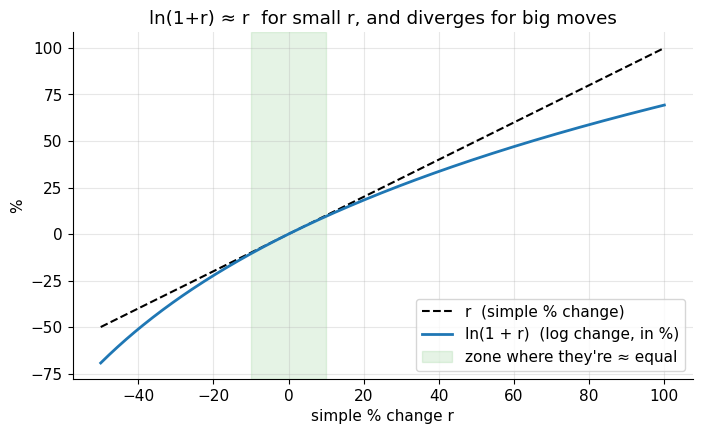

In [7]:
r = np.linspace(-0.5, 1.0, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r * 100, r * 100, "k--", label="r  (simple % change)")
ax.plot(r * 100, np.log(1 + r) * 100, lw=2, label="ln(1 + r)  (log change, in %)")
ax.axvspan(-10, 10, alpha=0.12, color="tab:green", label="zone where they're ≈ equal")
ax.set_xlabel("simple % change r"); ax.set_ylabel("%")
ax.set_title("ln(1+r) ≈ r  for small r, and diverges for big moves")
ax.legend(); plt.show()

---
# Part 4: *When* do logs show up? Log scales and the "straight line" trick

Rule of thumb: **reach for a log whenever the thing you care about changes by *ratios* (percentages, fold-changes, doublings) rather than by fixed amounts.**

- Linear thinking: "+10 cases per day." Equal **differences** matter.
- Log thinking: "+10% per day," "doubles every 3 days." Equal **ratios** matter.

### Why a log chart straightens exponential growth
If `y = y₀ · (1+g)ᵗ`, then taking logs: `log y = log y₀ + t · log(1+g)`. That's the equation of a **straight line** whose **slope is the growth rate** (in log units).

> **On a log-axis chart, steady percentage growth is a straight line. A steeper line = faster growth. A curve bending up = *accelerating* growth. A curve bending down = growth that is *slowing*, even if the raw numbers still climb.**

Toggle the axis and slide the growth rate to see for yourself.

In [8]:
def scale_demo(growth_pct=40, scale="linear"):
    t = np.arange(0, 31)
    y = 100 * (1 + growth_pct / 100) ** t
    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.plot(t, y, "o-", ms=4)
    ax.set_yscale(scale)
    ax.set_xlabel("time period"); ax.set_ylabel("value")
    ax.set_title(f"Steady {growth_pct}% growth per period, {scale} y-axis")
    plt.show()
    slope = np.polyfit(t, np.log(y), 1)[0]
    print(f"Slope of the straight line on log chart = ln(1 + {growth_pct/100:.2f}) = {slope:.4f}")
    print(f"→ Growth is x{(1+growth_pct/100):.2f} per period; value after 30 periods = {y[-1]:,.0f}")

interact(scale_demo,
         growth_pct=w.IntSlider(value=40, min=1, max=100, description="growth %"),
         scale=w.ToggleButtons(options=["linear", "log"], description="y-axis"));

interactive(children=(IntSlider(value=40, description='growth %', min=1), ToggleButtons(description='y-axis', …

**Two things to notice**
1. On the **linear** chart, low-growth periods early on look like *nothing happened*, then the end explodes. You can't see the early story.
2. On the **log** chart, the line is straight at *any* growth rate. The slope tells you the rate, and you can compare 5% growth and 50% growth at a glance.

### Squeezing huge ranges
A log axis is also how you show things that span many **orders of magnitude** on one picture:

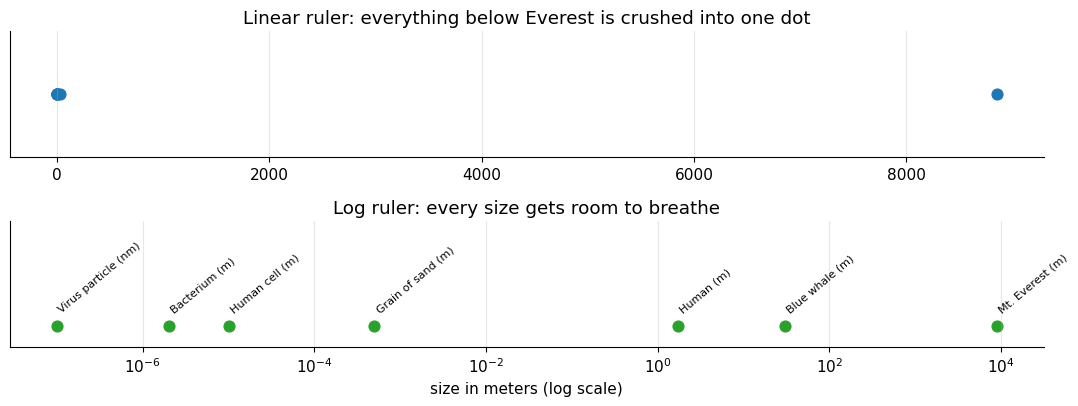

In [9]:
things = {
    "Virus particle (nm)": 100e-9, "Bacterium (m)": 2e-6, "Human cell (m)": 1e-5,
    "Grain of sand (m)": 5e-4, "Human (m)": 1.7, "Blue whale (m)": 30, "Mt. Everest (m)": 8849,
}
names = list(things); vals = np.array(list(things.values()))
fig, ax = plt.subplots(2, 1, figsize=(11, 4.2))
ax[0].scatter(vals, np.zeros_like(vals), s=60)
ax[0].set_title("Linear ruler: everything below Everest is crushed into one dot"); ax[0].set_yticks([])
ax[1].scatter(vals, np.zeros_like(vals), s=60, color="tab:green"); ax[1].set_xscale("log")
for nm, v in zip(names, vals):
    ax[1].annotate(nm, (v, 0), rotation=40, xytext=(0, 10), textcoords="offset points", fontsize=8)
ax[1].set_title("Log ruler: every size gets room to breathe"); ax[1].set_yticks([]); ax[1].set_ylim(-0.1, 0.5)
ax[1].set_xlabel("size in meters (log scale)")
plt.tight_layout(); plt.show()

---
# Part 5: Finance, where logs answer *"how long?"* and *"how much, really?"*

Compounding means **multiplying by (1 + r) once per period**. After *n* periods:

> **Future value = Present value × (1 + r)ⁿ**

If you know *n* you just compute a power. But the most useful financial question is usually the reverse: **how many periods until I reach my goal?** That's *"solve for the exponent"* → **a logarithm**.

> **n = ln(FV / PV) / ln(1 + r)**

### 5a. Doubling time and the Rule of 72
Set FV/PV = 2: `n = ln 2 / ln(1+r)`. Since `ln 2 ≈ 0.693` and `ln(1+r) ≈ r`, we get **n ≈ 69.3 / (r in %)**. Finance people use **72** instead of 69.3 because it has many divisors (2, 3, 4, 6, 8, 9, 12) *and* corrects for `ln(1+r)` being slightly smaller than `r` at typical rates. You've been using logs all along without knowing it.

rate %,exact years to double,Rule of 72,Rule of 69.3,72 error %
1,69.660000,72.000000,69.300000,3.360000
2,35.000000,36.000000,34.650000,2.850000
3,23.450000,24.000000,23.100000,2.350000
4,17.670000,18.000000,17.320000,1.850000
6,11.900000,12.000000,11.550000,0.880000
8,9.010000,9.000000,8.660000,-0.070000
10,7.270000,7.200000,6.930000,-1.000000
12,6.120000,6.000000,5.780000,-1.900000
15,4.960000,4.800000,4.620000,-3.220000
20,3.800000,3.600000,3.460000,-5.310000


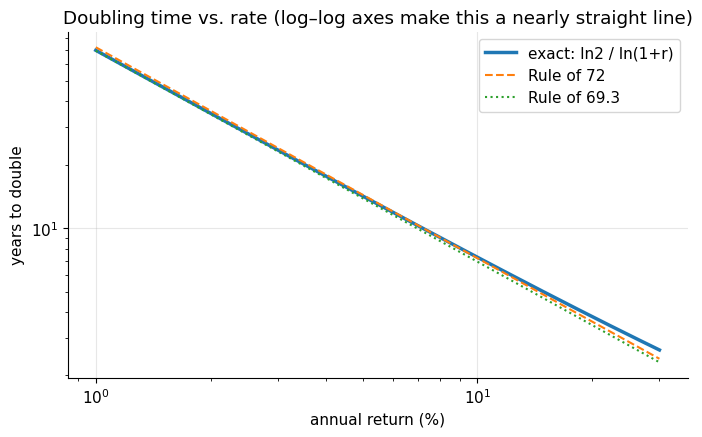

In [10]:
rates = np.array([1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 30])
exact = np.log(2) / np.log(1 + rates / 100)
df = pd.DataFrame({
    "rate %": rates,
    "exact years to double": exact,
    "Rule of 72": 72 / rates,
    "Rule of 69.3": 69.3 / rates,
})
df["72 error %"] = (df["Rule of 72"] / df["exact years to double"] - 1) * 100
display(df.round(2).style.hide(axis="index"))

rr = np.linspace(1, 30, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rr, np.log(2) / np.log(1 + rr / 100), lw=2.5, label="exact: ln2 / ln(1+r)")
ax.plot(rr, 72 / rr, "--", label="Rule of 72")
ax.plot(rr, 69.3 / rr, ":", label="Rule of 69.3")
ax.set_yscale("log"); ax.set_xscale("log")
ax.set_xlabel("annual return (%)"); ax.set_ylabel("years to double")
ax.set_title("Doubling time vs. rate (log–log axes make this a nearly straight line)")
ax.legend(); plt.show()

### 5b. "When will I get there?" calculator
Pick a starting amount, a goal, and a growth rate. The log formula gives the time instantly; the chart lets you see it on **linear** or **log** axes. On the log axis, your money's path is a straight line and the goal is just a horizontal line it crosses.

In [11]:
def goal_time(pv=10_000, goal=50_000, rate_pct=7.0, scale="linear"):
    r = rate_pct / 100
    n_star = np.log(goal / pv) / np.log(1 + r)
    horizon = max(5, n_star * 1.3)
    t = np.linspace(0, horizon, 300)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.plot(t, pv * (1 + r) ** t, lw=2.5, label=f"{pv:,.0f} growing at {rate_pct:.1f}%/yr")
    ax.axhline(goal, color="tab:red", ls="--", label=f"goal {goal:,.0f}")
    ax.axvline(n_star, color="tab:red", ls=":")
    ax.scatter([n_star], [goal], color="tab:red", zorder=5)
    ax.set_yscale(scale); ax.set_xlabel("years"); ax.set_ylabel("value")
    ax.set_title(f"Reach the goal in {n_star:.2f} years   ({scale} axis)")
    ax.legend(); plt.show()
    cagr_check = (goal / pv) ** (1 / n_star) - 1
    print(f"n = ln({goal:,.0f}/{pv:,.0f}) / ln(1+{r:.3f}) = {np.log(goal/pv):.4f} / {np.log(1+r):.4f} = {n_star:.2f} years")
    print(f"Check: {pv:,.0f} × (1+{r:.3f})^{n_star:.2f} = {pv*(1+r)**n_star:,.0f}   ✔")
    print(f"Doubling time at this rate: {np.log(2)/np.log(1+r):.2f} years")

interact(goal_time,
         pv=w.FloatLogSlider(value=10_000, base=10, min=2, max=7, step=0.05, description="start $"),
         goal=w.FloatLogSlider(value=50_000, base=10, min=2, max=8, step=0.05, description="goal $"),
         rate_pct=w.FloatSlider(value=7, min=0.5, max=25, step=0.5, description="rate %/yr"),
         scale=w.ToggleButtons(options=["linear", "log"], description="y-axis"));

interactive(children=(FloatLogSlider(value=10000.0, description='start $', max=7.0, min=2.0, step=0.05), Float…

**Try:** set the rate to 1% and the goal to 10× your start. Then 10%. Watch how brutally the rate controls the time, and notice it's `ln(goal/start)` (the *size of the ask*) divided by `ln(1+r)` (the *speed of the ride*).

### 5c. Why finance professionals use *log returns*
The famous trap: **a stock rises 50%, then falls 50%. Are you flat?**

No: $100 → $150 → $75. You're down 25%. Simple percentages **don't add**. Log returns do:

In [12]:
p0, p1, p2 = 100, 150, 75
simple = np.array([p1/p0 - 1, p2/p1 - 1])
logret = np.log([p1/p0, p2/p1])
print(f"Simple returns : {simple[0]:+.1%}, {simple[1]:+.1%}   sum = {simple.sum():+.1%}   (says: flat. WRONG.)")
print(f"Log returns    : {logret[0]:+.4f}, {logret[1]:+.4f}   sum = {logret.sum():+.4f}")
print(f"ln(75/100)     : {np.log(p2/p0):+.4f}   <- log returns add up to the true total ✔")
print(f"exp(sum)-1     : {np.exp(logret.sum())-1:+.1%}   <- convert back to a plain % change")

Simple returns : +50.0%, -50.0%   sum = +0.0%   (says: flat. WRONG.)
Log returns    : +0.4055, -0.6931   sum = -0.2877
ln(75/100)     : -0.2877   <- log returns add up to the true total ✔
exp(sum)-1     : -25.0%   <- convert back to a plain % change


Because log returns **add**, you can average them, take standard deviations, and scale volatility by √time without the math fighting you. Let's verify on a simulated stock. Slide the volatility and watch how far the "sum of simple returns" drifts from the truth, while log returns stay exact.

In [13]:
def returns_demo(seed=3, years=5, vol_pct=20):
    rng = np.random.default_rng(seed)
    n = 252 * years
    daily_log = rng.normal(0.07 / 252, (vol_pct / 100) / np.sqrt(252), n)
    price = 100 * np.exp(np.concatenate([[0], np.cumsum(daily_log)]))
    simple_daily = price[1:] / price[:-1] - 1
    true_total = price[-1] / price[0] - 1
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(price); ax[0].set_title(f"Simulated price path ({years} yrs, {vol_pct}% vol)")
    ax[0].set_xlabel("trading day"); ax[0].set_ylabel("price")
    ax[1].hist(daily_log * 100, bins=50, alpha=0.8)
    ax[1].set_title("Daily log returns (%)"); ax[1].set_xlabel("%")
    plt.tight_layout(); plt.show()
    print(f"True total return                       : {true_total:+.2%}")
    print(f"exp(sum of daily LOG returns) − 1       : {np.exp(daily_log.sum())-1:+.2%}   ← exact")
    print(f"product of (1+simple) − 1               : {np.prod(1+simple_daily)-1:+.2%}   ← exact (but clumsy)")
    print(f"naive SUM of daily simple returns       : {simple_daily.sum():+.2%}   ← drifts away from truth")

interact(returns_demo,
         seed=w.IntSlider(value=3, min=0, max=50, description="random seed"),
         years=w.IntSlider(value=5, min=1, max=20, description="years"),
         vol_pct=w.IntSlider(value=20, min=5, max=80, description="vol %"));

interactive(children=(IntSlider(value=3, description='random seed', max=50), IntSlider(value=5, description='y…

### 5d. CAGR is a log in disguise
*Compound Annual Growth Rate* answers: "what constant yearly rate turns *start* into *end* over *T* years?"

> **CAGR = exp( ln(end/start) / T ) − 1**

Read it right to left: `ln(end/start)` is the **total** growth in log units; dividing by *T* gives the **per-year** log growth (logs add, so we can split evenly!); `exp` converts back to a percentage.

In [14]:
def cagr(start, end, years):
    return np.exp(np.log(end / start) / years) - 1

print(f"$25,000 → $61,000 over 9 years: CAGR = {cagr(25_000, 61_000, 9):.2%}")
print(f"Same, via the root formula   : {(61_000/25_000)**(1/9) - 1:.2%}   (identical)")
print(f"Budget grows 100 → 160 over 8 yrs: CAGR = {cagr(100, 160, 8):.2%}/yr")

$25,000 → $61,000 over 9 years: CAGR = 10.42%
Same, via the root formula   : 10.42%   (identical)
Budget grows 100 → 160 over 8 yrs: CAGR = 6.05%/yr


---
# Part 6: Immunization, where logs describe outbreaks, immunity, and progress

Epidemiology is a log-lover's paradise because **infection, immunity, and elimination are all multiplicative processes.**

## 6a. Outbreak growth: R, generation time, doubling time, and what vaccination does to them
**Simple model:** each case infects **R** people on average, once per **generation time** *Tg*. After *n* generations, cases = `I₀ · Rⁿ`.

- **Growth** (R > 1) → *doubling time* = `Tg · ln 2 / ln R`
- **Decline** (R < 1) → *halving time* = `Tg · ln 2 / |ln R|`
- **Time to reach a target** = `Tg · ln(target / I₀) / ln R`

**Vaccination** lowers R: `R_eff = R₀ × (1 − coverage × efficacy)`. The magic threshold is **R_eff = 1**, where `ln R_eff = 0` and the outbreak neither grows nor shrinks. The herd-immunity threshold falls out of that:
`coverage × efficacy ≥ 1 − 1/R₀`.

*(Illustrative textbook numbers, not forecasts: measles R₀ ≈ 12–18, generation time ≈ 12 days, two-dose efficacy ≈ 97%.)*

In [15]:
def outbreak(R0=15.0, Tg=12, coverage_pct=80, efficacy_pct=97, I0=10, target=10_000):
    cov, eff = coverage_pct / 100, efficacy_pct / 100
    Reff = max(R0 * (1 - cov * eff), 1e-6)   # floor avoids log(0) at 100% protection
    hit = 1 - 1 / R0                     # herd immunity threshold (immune fraction)
    cov_needed = hit / eff               # coverage needed given efficacy
    days = np.linspace(0, 240, 400)
    cases = I0 * Reff ** (days / Tg)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
    for a_, sc in zip(ax, ["linear", "log"]):
        a_.plot(days, cases, lw=2.5, color="tab:red" if Reff > 1 else "tab:green")
        a_.axhline(target, color="gray", ls="--", lw=1)
        a_.set_yscale(sc); a_.set_xlabel("days"); a_.set_ylabel("cases")
        a_.set_title(f"{sc} axis")
    ax[0].set_ylim(0, target * 3)
    ax[1].set_ylim(0.1, max(target * 100, I0 * 10))
    fig.suptitle(f"R_eff = {R0:g} × (1 − {cov:.2f}×{eff:.2f}) = {Reff:.2f}", fontweight="bold")
    plt.tight_layout(); plt.show()

    print(f"Herd-immunity threshold = 1 − 1/R0 = {hit:.1%} immune.  With {eff:.0%} efficacy, coverage must be ≥ {cov_needed:.1%}"
          + ("  (>100%: unreachable with this vaccine alone)" if cov_needed > 1 else ""))
    if np.isclose(Reff, 1.0, atol=1e-3):
        print("R_eff ≈ 1: ln(R_eff) ≈ 0 → cases are flat. Knife-edge!")
    elif Reff > 1:
        td = Tg * np.log(2) / np.log(Reff)
        tt = Tg * np.log(target / I0) / np.log(Reff)
        print(f"GROWING: doubling time = {Tg}·ln2/ln({Reff:.2f}) = {td:.1f} days. Reaches {target:,} cases in ~{tt:.0f} days.")
    else:
        th = Tg * np.log(2) / abs(np.log(Reff))
        print(f"DECLINING: halving time = {Tg}·ln2/|ln({Reff:.2f})| = {th:.1f} days. Outbreak fizzles out.")

interact(outbreak,
         R0=w.FloatSlider(value=15, min=1.2, max=18, step=0.1, description="R0"),
         Tg=w.IntSlider(value=12, min=2, max=30, description="gen. time (d)"),
         coverage_pct=w.IntSlider(value=80, min=0, max=100, description="coverage %"),
         efficacy_pct=w.IntSlider(value=97, min=50, max=100, description="efficacy %"),
         I0=w.IntSlider(value=10, min=1, max=100, description="initial cases"),
         target=w.IntSlider(value=10_000, min=100, max=1_000_000, step=100, description="target cases"));

interactive(children=(FloatSlider(value=15.0, description='R0', max=18.0, min=1.2), IntSlider(value=12, descri…

**Experiments**
1. Start at 80% coverage (outbreak explodes). Increase coverage until the red line turns green. Where does it flip? Compare with the printed threshold.
2. Set R₀ = 15, efficacy = 97%, coverage = 95%. Still **growing** (R_eff ≈ 1.2)! Measles needs *very* high coverage because R₀ is so large; this is why 95% is the target and pockets of low coverage matter.
3. Compare the **left (linear)** and **right (log)** charts. The log chart shows the decline *as clearly as* the growth. The linear chart makes a decline look like "it's over" long before the case count is really small.
4. Lower R₀ to ~2 (a flu-like pathogen). The doubling time stretches out; the required coverage drops to ~50%.

## 6b. Antibody titers: why immunologists live on a log₂ scale
Antibody levels are measured by **serial 2-fold dilutions** (1:8, 1:16, 1:32, …). Each step is a *doubling*, so titers are *inherently* multiplicative, and their natural unit is **log₂**.

That's why vaccine studies report the **Geometric Mean Titer (GMT)**:

> **GMT = exp( mean( ln(titers) ) )**

i.e. *average the logs, then undo the log*. The ordinary (arithmetic) mean is hijacked by a single extreme responder. Add a high-titer outlier below and watch.

In [16]:
base_titers = np.array([16, 32, 32, 64, 64, 64, 128, 128, 256])

def gmt_demo(outlier_log2=8):
    outlier = 2 ** outlier_log2
    titers = np.append(base_titers, outlier)
    amean = titers.mean()
    gmt = np.exp(np.log(titers).mean())
    med = np.median(titers)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].bar(range(len(titers)), titers, color=["tab:blue"] * 9 + ["tab:red"])
    ax[0].axhline(amean, color="k", ls="--", label=f"arithmetic mean = {amean:,.0f}")
    ax[0].axhline(gmt, color="tab:green", lw=2, label=f"GMT = {gmt:,.0f}")
    ax[0].set_title("Titers on a linear axis (outlier dominates)"); ax[0].legend()
    ax[0].set_xlabel("participant"); ax[0].set_ylabel("titer (1:x)")
    ax[1].bar(range(len(titers)), np.log2(titers), color=["tab:blue"] * 9 + ["tab:red"])
    ax[1].axhline(np.log2(gmt), color="tab:green", lw=2, label=f"log2(GMT) = {np.log2(gmt):.2f}")
    ax[1].set_title("Same data as log₂(titer): each step = one doubling"); ax[1].legend()
    ax[1].set_xlabel("participant"); ax[1].set_ylabel("log₂(titer)")
    plt.tight_layout(); plt.show()
    print(f"Outlier titer 1:{outlier:,}  |  arithmetic mean = {amean:,.0f}  |  GMT = {gmt:,.0f}  |  median = {med:,.0f}")
    print("→ The GMT barely budges when one person is extreme; the arithmetic mean gets dragged.")

interact(gmt_demo, outlier_log2=w.IntSlider(value=8, min=5, max=16, description="outlier = 2^"));

interactive(children=(IntSlider(value=8, description='outlier = 2^', max=16, min=5), Output()), _dom_classes=(…

### Waning immunity: half-life, thresholds, and booster timing
If antibodies **halve** every *h* months, then `titer(t) = T₀ · 2^(−t/h)`. The time until you fall below a **protective threshold** is a log:

> **t = h · log₂(T₀ / threshold)**: *"how many halvings can I afford?" × "months per halving."*

On a log axis, exponential decay is a **straight line down**, and you can read off when it crosses the threshold. *(Numbers below are illustrative. Real correlates of protection and half-lives are pathogen-specific.)*

In [17]:
def waning(T0=640, half_life_months=18, threshold=40):
    t = np.linspace(0, max(12, 6 * half_life_months), 400)
    titer = T0 * 2 ** (-t / half_life_months)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.plot(t, titer, lw=2.5, label="antibody titer")
    ax.axhline(threshold, color="tab:red", ls="--", label=f"protective threshold = {threshold}")
    ax.set_yscale("log", base=2)
    ax.set_yticks([2 ** k for k in range(0, 15)]); ax.set_yticklabels([str(2 ** k) for k in range(0, 15)])
    ax.set_ylim(1, max(T0 * 2, 16)); ax.set_xlabel("months since peak"); ax.set_ylabel("titer (log₂ axis)")
    if T0 > threshold:
        t_star = half_life_months * np.log2(T0 / threshold)
        ax.axvline(t_star, color="tab:red", ls=":"); ax.scatter([t_star], [threshold], color="tab:red", zorder=5)
        ax.set_title(f"Falls below threshold at {t_star:.1f} months")
        print(f"halvings available = log2({T0}/{threshold}) = {np.log2(T0/threshold):.2f}")
        print(f"time = {half_life_months} months × {np.log2(T0/threshold):.2f} = {t_star:.1f} months ({t_star/12:.1f} years)")
    else:
        ax.set_title("Already at/below threshold at the peak")
        print("Peak titer is not above the threshold: no protection window.")
    ax.legend(); plt.show()

interact(waning,
         T0=w.IntSlider(value=640, min=10, max=20_000, step=10, description="peak titer"),
         half_life_months=w.IntSlider(value=18, min=2, max=120, description="half-life (mo)"),
         threshold=w.IntSlider(value=40, min=2, max=2000, description="threshold"));

interactive(children=(IntSlider(value=640, description='peak titer', max=20000, min=10, step=10), IntSlider(va…

**Try:** double the peak titer. Protection extends by **exactly one half-life**, no matter how big or small the numbers. *A doubling of the starting level buys one more halving of runway.* That's `log₂(2) = 1` in action, and why a booster that boosts titers **4×** buys two half-lives of protection.

## 6c. The elimination countdown: why "99% reduction" is not "almost there"
Suppose cases fall by a fixed **percentage** each year (say −30%). Cases never hit zero by simple exponential decay. They shrink by a ratio each year. The time to fall from *N* cases to a target *M* is again a log:

> **years = ln(M / N) / ln(1 − d)**   (where *d* is the annual fractional decline)

Both numerator and denominator are negative, so the answer is positive. Compare with the *linear intuition* "if I cut 30% of the starting number each year I'd be at zero in 3.3 years." That intuition is wrong for percentage declines.

In [18]:
def countdown(start_cases=50_000, decline_pct=30, target=1):
    d = decline_pct / 100
    if target >= start_cases:
        print("Target is at or above the starting cases: nothing to count down. Lower the target.")
        return
    years_needed = np.log(target / start_cases) / np.log(1 - d)
    yrs = np.arange(0, int(np.ceil(years_needed)) + 6)
    cases = start_cases * (1 - d) ** yrs
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    for a_, sc in zip(ax, ["linear", "log"]):
        a_.plot(yrs, cases, "o-", ms=4)
        a_.axhline(target, color="tab:red", ls="--")
        a_.axvline(years_needed, color="tab:red", ls=":")
        a_.set_yscale(sc); a_.set_xlabel("years"); a_.set_ylabel("cases"); a_.set_title(f"{sc} axis")
    ax[1].set_ylim(min(target, 1) * 0.5, start_cases * 2)
    plt.tight_layout(); plt.show()
    print(f"years = ln({target:,}/{start_cases:,}) / ln(1 − {d:.2f}) = {np.log(target/start_cases):.3f} / {np.log(1-d):.3f} = {years_needed:.1f} years")
    print(f"Linear 'intuition' (cut {d:.0%} of the starting number each year): zero in {1/d:.1f} years  ← misleading")
    print(f"Each year cuts cases by a factor of {1-d:.2f}; the half-life of the epidemic is {np.log(0.5)/np.log(1-d):.1f} years.")
    print(f"Speed-up check: doubling the decline rate from {decline_pct}% to {min(2*decline_pct, 99)}% → "
          f"{np.log(target/start_cases)/np.log(1-min(2*d, .99)):.1f} years")

interact(countdown,
         start_cases=w.FloatLogSlider(value=50_000, base=10, min=1, max=7, step=0.05, description="start cases"),
         decline_pct=w.IntSlider(value=30, min=5, max=90, description="decline %/yr"),
         target=w.FloatLogSlider(value=1, base=10, min=-1, max=3, step=0.05, description="target cases"));

interactive(children=(FloatLogSlider(value=50000.0, description='start cases', max=7.0, min=1.0, step=0.05), I…

**Takeaways:**
- The **log chart** shows the program is "on track" if the line is straight and steeply sloped, even while the raw numbers are still large.
- **Halving time** (a log idea) is a clear way to communicate progress: *"cases halve every 2 years."*
- A **fold-reduction** is the natural language: a **10-fold** drop = 1 log₁₀; a **100-fold** drop = 2 log₁₀. The same language is used for viral load, bacterial counts in disinfection, and vaccine potency.

### Bonus: orders of magnitude and comparing very different countries
When you compare case counts, population sizes, or funding levels across countries, you want to ask "**how many *fold* bigger?**", not "how many *more*?" A log₁₀ axis puts a country with 100 cases and a country with 100,000 on the same chart and shows both trends clearly. Next time you plot panel data in `pandas`, try `df.plot(logy=True)` and see which trends you were missing.

---
# Part 7: Cheat sheet and practice

### The mental model
> **log = "how many multiplications?"**
> **exp = "do that many multiplications."** They undo each other.

### Formulas to keep
| Need | Formula |
|---|---|
| Solve for time | `n = ln(final/start) / ln(growth factor)` |
| Doubling time | `ln 2 / ln(1+r)` ≈ `72 / r%` |
| Halving time (decay) | `ln 2 / │ln(factor)│` |
| Average of ratios | `exp(mean(ln(values)))` (geometric mean) |
| Combine growth over periods | add the logs |
| Change base | `log_b(x) = ln x / ln b` |
| CAGR | `exp(ln(end/start)/T) − 1` |

### When to reach for a log (spot the signals)
1. **The question is "how long until…" or "how many times…"** → solve for an exponent.
2. **The thing grows or shrinks by a percentage**, not a fixed amount → log scale / log returns.
3. **Data spans orders of magnitude** (titers, case counts, funding sizes, populations) → log axis.
4. **You want to average ratios or fold-changes** → geometric mean = average in log space.
5. **You want to compare growth rates by eye** → straight lines on a log chart; steeper = faster.

### When *not* to
Quantities that change by fixed **amounts**, can be zero or negative (cash flow, net change), or where equal *differences* (not ratios) are what matter. Logs of zero or negatives are undefined.

---
### Practice problems
Try each one in the scratch cell below *before* opening the answer.

1. How many doublings take you from 1 to 1 billion?
2. How many years to grow \$10,000 to \$25,000 at 6%/year?
3. An outbreak has R_eff = 0.8 with a 14-day generation time. How many days to fall from 500 cases to under 5?
4. A vaccine produces a titer of 640 with a 18-month half-life; protection needs ≥ 40. How many months of protection?
5. Two groups have titers of 10 and 1,000. What's the GMT? Why is it a better "typical" value than 505?
6. *(Conceptual)* A chart shows a line that is straight on a log axis with slope 0.0953 (natural log) per month. What's the monthly growth rate? *(Hint: slope = ln(1+g).)*

In [19]:
# Scratch space: work the practice problems here
# e.g.  np.log(25_000/10_000) / np.log(1.06)

<details>
<summary><b>Click for answers</b></summary>

1. `log2(1e9) = ln(1e9)/ln(2) ≈ 29.9` doublings. (About 30! This is why "30 days of doubling" stories sound astonishing.)
2. `ln(2.5)/ln(1.06) = 0.9163/0.0583 ≈ 15.7` years.
3. Generations `n = ln(5/500)/ln(0.8) = (−4.605)/(−0.2231) ≈ 20.6`; days ≈ 20.6 × 14 ≈ **289 days**.
4. `log2(640/40) = log2(16) = 4` halvings × 18 months = **72 months (6 years)**.
5. GMT = `√(10 × 1000) = 100`. The arithmetic mean (505) is dominated by the 1,000. The group's "typical" fold-level is the *middle in ratio terms*: 100 is 10× above one and 10× below the other.
6. `g = exp(0.0953) − 1 ≈ 0.10`, i.e. **10% per month**.

</details>

---
**You made it.** If you remember only one sentence: *a logarithm counts multiplications, so it turns "how long?" questions about growth into simple division.*